## 📋 Executive Summary
This analysis identifies key revenue drivers, customer behavior patterns, and operational performance across the **Olist Brazilian E-Commerce** platform using SQL-based analysis and data visualization.

**Primary Insight:** `67`% of customers (63,827) fall into "At Risk" or "Needs Attention" segments — indicating a serious **retention problem**, not an acquisition one.  
**Top Revenue Driver:** São Paulo state alone contributes **`$5.92M (38%)`** of total revenue, with Health & Beauty as the #1 product category at **`$1.44M`**.  
**Operational Win:** **`89%`** of orders are delivered before the estimated date, yet **`7,827` delayed orders** represent the highest churn risk.  
**Business Goal:** Re-engage disengaged customers through RFM-targeted campaigns and transition high-freight regions into local logistics hubs.

---

## 📊 Olist E-Commerce Business Analysis

## 📌 Project Overview
E-commerce platforms generate vast amounts of transactional data across customers, products, payments, and logistics. Extracting actionable insights from this data is critical for improving revenue, retention, and operational efficiency.

This project analyzes the **Olist Brazilian E-Commerce dataset** using SQL queries, exploratory data analysis (EDA), and data visualization. The goal is to identify high-performing product categories, understand customer purchasing behavior, evaluate payment trends, and assess delivery performance.

## 🎯 Objectives
- Perform data cleaning and preprocessing across 5 relational datasets
- Analyze business KPIs, product performance, and regional revenue using SQL
- Segment customers using the **RFM framework** (Recency, Frequency, Monetary)
- Visualize key trends across revenue, payments, cities, and delivery
- Generate actionable business recommendations for retention and growth

## 🛠 Tools & Technologies
- Python
- Pandas
- SQLite
- Seaborn & Matplotlib
- Jupyter Notebook

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment Setup Complete.")

Environment Setup Complete.


In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")

orders = pd.read_csv("olist_orders_dataset.csv")

order_items = pd.read_csv("olist_order_items_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

payment = pd.read_csv("olist_order_payments_dataset.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


# 🧹 Data Cleaning & Preprocessing

In this step, the datasets are cleaned and standardized to prepare them for SQL analysis and business insights generation.

The preprocessing process includes:
- Converting timestamp columns into datetime format
- Removing duplicate records
- Handling missing values
- Verifying dataset consistency

In [3]:
# Convert order timestamp columns into datetime format

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [4]:
# Remove duplicate rows from all datasets

dfs = [customers, orders, order_items, products, payment]

customers, orders, order_items, products, payment = [
    df.drop_duplicates() for df in dfs
]

In [5]:
# Fill missing values in numerical and categorical columns

for df in [customers, orders, order_items, products, payment]:

    # Fill numeric columns with 0
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    # Fill object/string columns with 'Unknown'
    object_cols = df.select_dtypes(include='object').columns
    df[object_cols] = df[object_cols].fillna('Unknown')

    # Fill datetime columns with NaT (though they usually are NaT by default)
datetime_cols = df.select_dtypes(include=['datetime64']).columns
df[datetime_cols] = df[datetime_cols].fillna(pd.NaT)

In [6]:
# exporting cleaned datasets

datasets = {
    'customers_cleaned': customers,
    'orders_cleaned': orders,
    'order_items_cleaned': order_items,
    'products_cleaned': products,
    'payments_cleaned': payment
}

for name, df in datasets.items():
    df.to_csv(f'{name}.csv', index=False)


## 📌 Cleaning Summary

- Converted timestamp columns into datetime format
- Removed duplicate records across all primary datasets
- Filled missing numerical values with `0`
- Filled missing categorical values with `"Unknown"`
- Preserved missing datetime values for accurate business and delivery analysis
- Prepared datasets for SQL-based relational analysis

# 🗄 Database Setup

After preprocessing the datasets, the cleaned tables are loaded into an SQLite database to enable SQL-based relational analysis and business querying.

In [7]:
# Create SQLite connection
conn = sqlite3.connect('ecommerce_intelligence.db')

def run_query(query):
    return pd.read_sql(query, conn)

print("Dataset loaded and run_query function defined")

Dataset loaded and run_query function defined


In [8]:
# Loading tables into database

customers.to_sql('customers', conn, if_exists='replace', index=False)

orders.to_sql('orders', conn, if_exists='replace', index=False)

order_items.to_sql('order_items', conn, if_exists='replace', index=False)

products.to_sql('products', conn, if_exists='replace', index=False)

payment.to_sql('payments', conn, if_exists='replace', index=False)

103886

In [9]:
# Testing

run_query("""
SELECT name FROM sqlite_master
WHERE type='table';
""")

,name
0,customers
1,orders
2,order_items
3,products
4,payments


# 📊 SQL-Based Business Analysis

After loading the cleaned datasets into SQLite, SQL queries are used to analyze customer behavior, sales performance, payment trends, and operational insights from the e-commerce data.

# 📦 Business Overview Analysis

This section provides a high-level overview of the e-commerce platform’s overall business performance using SQL-based analysis.

Key performance indicators (KPIs) analyzed include:
- Total revenue generated
- Total number of orders
- Total customer count
- Average order value

These metrics help establish a foundational understanding of the platform’s scale, customer activity, and overall sales performance

In [10]:
overview = run_query("""
                     SELECT 
                         ROUND(SUM(price+freight_value), 2) AS
                         total_revenue
                         FROM order_items;
                         """)

print(f"Total Revenue : ${overview['total_revenue'][0]:,.2f}")

Total Revenue : $15,843,553.24


In [11]:
Total_orders = run_query("""
                         SELECT 
                              COUNT(DISTINCT order_id) AS
                              total_orders
                              FROM orders;
                              """)

print(f"Total Orders :{Total_orders['total_orders'][0]:,.0f}")

Total Orders :99,441


In [12]:
Total_customers = run_query("""
                            SELECT
                                 COUNT(DISTINCT customer_unique_id) AS
                                 total_customers
                                 FROM customers;
                                 """)

print(f"Total Orders :{Total_orders['total_orders'][0]:,.0f}")

Total Orders :99,441


In [13]:
Avg_ord_val = run_query ("""
                         SELECT
                              ROUND(AVG(price+freight_value), 2) AS
                              avg_order_value
                              FROM order_items
                              """)

print(f"Average Order Value :{Avg_ord_val['avg_order_value'][0]:,.0f}")

Average Order Value :141


## 📌 Insight

The business overview metrics provide a high-level understanding of platform performance, customer scale, and purchasing behavior. Revenue and order volume indicate overall marketplace activity, while average order value helps evaluate customer spending patterns

# 🛒 Product & Category Analysis

This section analyzes product performance across the e-commerce platform using SQL queries and relational joins

The analysis focuses on:
- Best-selling product categories
- Revenue-generating categories
- Product pricing patterns
- Customer purchasing behavior across categories

These insights help identify high-performing products and business-driving categories

## 📌 Highest Revenue-Generating Product Categories

This analysis identifies the product categories generating the highest overall revenue across the e-commerce platform.

The query combines product and order item data to evaluate category-level business performance based on total sales revenue.

In [14]:
# Top selling product categories

category_analysis = run_query("""
    SELECT 
        p.product_category_name AS product_category,
        COUNT(DISTINCT oi.order_id) AS total_orders,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_category_name
    ORDER BY total_revenue DESC
    LIMIT 10;
""")

category_analysis.index = category_analysis.index + 1

# Display the results
display(category_analysis)

,product_category,total_orders,total_revenue
1,beleza_saude,8836,1441248.07
2,relogios_presentes,5624,1305541.61
3,cama_mesa_banho,9417,1241681.72
4,esporte_lazer,7720,1156656.48
5,informatica_acessorios,6689,1059272.40
6,moveis_decoracao,6449,902511.79
7,utilidades_domesticas,5884,778397.77
8,cool_stuff,3632,719329.95
9,automotivo,3897,685384.32
10,ferramentas_jardim,3518,584219.21


## 📌 Insight: Revenue Drivers

The analysis shows that **Health & Beauty (`beleza_saude`)** is the platform's primary revenue engine, generating over **$1.44M**.

* **Revenue vs. Volume:** While **Bed/Bath/Table (`cama_mesa_banho`)** has the highest order volume (**9,417**), **Watches & Gifts (`relogios_presentes`)** generates more revenue despite lower sales, indicating a much higher **Average Order Value (AOV)**.
* **Strategy:** Focus marketing on high-margin categories like *Watches* to drive profitability, while using high-volume categories like *Bed & Bath* for customer retention.

## 📌 Most Ordered Product Categories

This analysis identifies the product categories with the highest number of customer orders across the platform.

The query helps measure customer demand and purchasing frequency across different product categories

In [15]:
# Highest revenue generating categories

most_ordered_prod_cat = run_query("""
                                  SELECT 
                                       p.product_category_name,
                                       COUNT(oi.order_id) AS total_orders
                                   FROM order_items oi
                                   JOIN products p
                                   ON oi.product_id = p.product_id
                                   GROUP BY p.product_category_name
                                   ORDER BY total_orders DESC
                                   LIMIT 10;
                                   """)
most_ordered_prod_cat.index = most_ordered_prod_cat.index + 1

# Display the results
display(most_ordered_prod_cat)

,product_category_name,total_orders
1,cama_mesa_banho,11115
2,beleza_saude,9670
3,esporte_lazer,8641
4,moveis_decoracao,8334
5,informatica_acessorios,7827
6,utilidades_domesticas,6964
7,relogios_presentes,5991
8,telefonia,4545
9,ferramentas_jardim,4347
10,automotivo,4235


## 📌 Insight: Order Volume & Demand

The platform experiences high transaction frequency in essential lifestyle categories:

* **Volume Leader :** **`cama_mesa_banho`** (Bed/Bath/Table) dominates with **11,115 orders**, proving to be the platform's strongest driver of customer traffic.
* **Core Demand :** The top 5 categories—including **Health & Beauty** and **Sports & Leisure**—all exceed **7,800 orders**, representing consistent, high-frequency purchasing behavior.
* **Strategic Value :** These categories are vital for **customer acquisition** and logistical efficiency, serving as the high-traffic "entry points" for the marketplace.

## 📌 Most Expensive Product Categories

This analysis identifies the product categories with the highest average selling prices across the platform.

The query helps highlight premium and high-value product segments within the marketplace.

In [16]:
expensive_categories = run_query("""
                                 SELECT 
                                      p.product_category_name,
                                      ROUND(AVG(oi.price), 2) AS avg_product_price
                                      FROM order_items oi
                                      JOIN products p
                                      ON oi.product_id = p.product_id
                                      GROUP BY p.product_category_name
                                      ORDER BY avg_product_price DESC
                                      LIMIT 10;
                                      """)
expensive_categories.index = expensive_categories.index + 1

display(expensive_categories)

,product_category_name,avg_product_price
1,pcs,1098.34
2,portateis_casa_forno_e_cafe,624.29
3,eletrodomesticos_2,476.12
4,agro_industria_e_comercio,342.12
5,instrumentos_musicais,281.62
6,eletroportateis,280.78
7,portateis_cozinha_e_preparadores_de_alimentos,264.57
8,telefonia_fixa,225.69
9,construcao_ferramentas_seguranca,208.99
10,relogios_presentes,201.14


## 📌 Insight: Premium & High-Ticket Segments

The analysis reveals a significant price gap between "essential" items and "specialized" segments:

* **Top Premium Category :** **PCs** (Computers) dominate with an average price of `$1,098.34`, nearly `8x higher` than the platform average `($141)`
* **High-Value Niches :** Categories like **Small Appliances** and **Agro Industry** average` $340–$620`
* **Strategic Leader :** **Watches & Gifts** balances high revenue with a premium `$201.14` average price

**Business Recommendation :** Target these categories with specialized marketing, such as installment payment plans, to reduce purchase friction

## 📌 Products with Highest Order Frequency

This analysis identifies the products that appear most frequently across customer orders.

The query helps determine highly demanded products and purchasing concentration within the marketplace.

In [17]:
highest_order_freq = run_query("""
                               SELECT 
                                    
                                    p.product_category_name,
                                    COUNT(oi.order_id) AS total_orders
                                    FROM order_items oi
                                    JOIN products p
                                    ON oi.product_id = p.product_id
                                    GROUP BY oi.product_id, p.product_category_name
                                    ORDER BY total_orders DESC
                                    LIMIT 10;
                                    """)

highest_order_freq.index = highest_order_freq.index + 1

display(highest_order_freq)

,product_category_name,total_orders
1,moveis_decoracao,527
2,cama_mesa_banho,488
3,ferramentas_jardim,484
4,ferramentas_jardim,392
5,ferramentas_jardim,388
6,ferramentas_jardim,373
7,informatica_acessorios,343
8,relogios_presentes,323
9,beleza_saude,281
10,informatica_acessorios,274


## 📌 Insight: High-Frequency "Anchor" Products
The marketplace relies on a core group of "hero" products to drive consistent traffic:

* **Top Seller** : A single Furniture & Decor item leads with 527 orders

* **Niche Loyalty** : Garden Tools dominates the top 10 list with 4 unique products, showing high repeat demand

* **Anchor Effect** : Essential categories (Bed/Bath, Health/Beauty) act as entry points for new customers

* **Strategic Value** : These items are critical for inventory safety stock and are prime candidates for cross-selling bundles to increase Average Order Value (AOV)

## 📌 Most Active Customer Cities

This analysis identifies the cities with the highest customer order activity across the platform

The query helps highlight regions with strong customer engagement and purchasing behavior

In [18]:
most_active_customer_cities = run_query("""
                                        SELECT
                                        c.customer_city AS City,
                                        COUNT(o.order_id) AS total_orders
                                        FROM customers c
                                        JOIN orders o
                                        ON c.customer_id = o.customer_id
                                        GROUP BY c.customer_city
                                        ORDER BY total_orders DESC
                                        LIMIT 10;
                                        """)
most_active_customer_cities.index = most_active_customer_cities.index + 1

display(most_active_customer_cities)

,City,total_orders
1,sao paulo,15540
2,rio de janeiro,6882
3,belo horizonte,2773
4,brasilia,2131
5,curitiba,1521
6,campinas,1444
7,porto alegre,1379
8,salvador,1245
9,guarulhos,1189
10,sao bernardo do campo,938


## 📌 Insight: Regional Market Concentration
Orders are heavily concentrated in Brazil’s primary economic hubs:

* **Market Leader** : São Paulo dominates with 15,540 orders, exceeding the combined volume of the next four cities

* **Tier 1 Hubs** : Rio de Janeiro and Belo Horizonte follow, confirming the Southeast as the platform's core region

* **Volume Gap** : A steep 50% drop in volume occurs between Rio and Belo Horizonte, highlighting a "long-tail" distribution

* **Strategic Value** : Focus logistics infrastructure and warehousing in São Paulo to minimize shipping costs and delivery times for the highest-density customer base

## 📌 States Generating Highest Revenue

This analysis identifies the states contributing the highest overall revenue across the e-commerce platform

The query combines customer, order, and sales data to evaluate regional business performance and revenue concentration

In [19]:
state_revenue = run_query("""
                          SELECT 
                          c.customer_state,
                          ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
                          FROM customers c
                          JOIN orders o
                          ON c.customer_id = o.customer_id
                          JOIN order_items oi
                          ON o.order_id = oi.order_id
                          GROUP BY c.customer_state
                          ORDER BY total_revenue DESC
                          LIMIT 10;
                          """)
state_revenue.index = state_revenue.index + 1

display(state_revenue)

,customer_state,total_revenue
1,SP,5921678.12
2,RJ,2129681.98
3,MG,1856161.49
4,RS,885826.76
5,PR,800935.44
6,BA,611506.67
7,SC,610213.60
8,DF,353229.44
9,GO,347706.93
10,ES,324801.91


## 📌 Insight: Regional Revenue Dominance
The financial landscape shows a heavy reliance on the Southeast region, creating a clear "tier" system for market presence:

* **Market Epicenter** : São Paulo (SP) is the undisputed leader, contributing $5.92M—nearly 3x more than the second-highest state (RJ)

* **Revenue Concentration** : The top three states (SP, RJ, MG) generate the vast majority of total revenue, indicating that purchasing power is highly centralized in Brazil’s industrial heartland

* **Expansion Opportunity** : Lower revenue in states like BA and SC suggests potential growth barriers, likely due to higher freight costs or longer delivery times, making them prime targets for localized logistics hubs

In [20]:
Top_customer_spending = run_query("""
                                  SELECT
                                  c.customer_unique_id,
                                  ROUND(SUM(price+freight_value),2) AS total_spent
                                  FROM customers c 
                                  JOIN orders o
                                  ON c.customer_id = o.customer_id
                                  JOIN order_items oi
                                  ON o.order_id = oi.order_id
                                  GROUP BY c.customer_unique_id
                                  ORDER BY total_spent DESC
                                  LIMIT 10;
                                  """)

Top_customer_spending.index = Top_customer_spending.index + 1

display(Top_customer_spending)

,customer_unique_id,total_spent
1,0a0a92112bd4c708ca5fde585afaa872,13664.08
2,da122df9eeddfedc1dc1f5349a1a690c,7571.63
3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
4,dc4802a71eae9be1dd28f5d788ceb526,6929.31
5,459bef486812aa25204be022145caa62,6922.21
6,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
7,4007669dec559734d6f53e029e360987,6081.54
8,5d0a2980b292d049061542014e8960bf,4809.44
9,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34
10,48e1ac109decbb87765a3eade6854098,4681.78


## 📌 Insight
**A small group of customers contributes a disproportionately large share of total revenue, highlighting the importance of high-value customer segments. Businesses can use this insight to improve customer retention strategies and personalized marketing efforts**

# 💳 Payment Analysis

This section analyzes customer payment behavior across the e-commerce platform using SQL-based analysis

The analysis focuses on:
- Most commonly used payment methods
- Installment payment behavior
- Payment methods associated with higher order values

These insights help understand customer transaction preferences and purchasing patterns

## 📌 Most Used Payment Methods

This analysis identifies the payment methods most frequently used by customers across the platform

In [21]:
Most_Used_Pay_method = run_query("""SELECT 
    payment_type ,
    COUNT(order_id) AS total_orders
FROM payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY total_orders DESC;
""")

display(Most_Used_Pay_method)

,payment_type,total_orders
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529


## 📌 Insight: Payment Method Dominance

The platform’s transaction landscape is heavily concentrated, with two methods accounting for nearly **93%** of all payments:

* **Primary Driver:** **Credit Card** is the undisputed leader with **76,795** transactions, representing approximately **74%** of the total volume.
* **Secondary Hub:** **Boleto** serves as the key alternative with **19,784** transactions (~19%), reflecting traditional Brazilian payment habits.
* **Marginal Methods:** **Vouchers** and **Debit Cards** play a minor role, combining for fewer than **7,500** transactions, indicating they are secondary to the core payment ecosystem.

## 📌 Average Installment Usage

This analysis measures the average number of payment installments used by customers during purchases.

In [22]:
Avg_installmenet_Usage = run_query("""
                                   SELECT
                                   ROUND(AVG(payment_installments), 2) AS avg_installments
                                   FROM payments
                                   """)

display(Avg_installmenet_Usage)

,avg_installments
0,2.85


## 📌 Insight: Installment-Driven Purchasing

The average of **2.85 installments** reveals a strategic reliance on credit to drive sales:

* **Credit Dependency:** With an average near 3, customers frequently split costs rather than paying upfront, making the platform's **74% credit card usage** the primary engine for conversion.
* **Affordability Bridge:** Installments act as a "financial cushion," allowing customers to purchase mid-to-high value items (like Health & Beauty or Electronics) by spreading the cost over several months.
* **Opportunity:** Increasing the maximum number of interest-free installments could further boost the **Average Order Value ($141)** by making premium "High-Ticket" items more accessible.

## 📌 Payment Type vs Average Order Value

This analysis compares payment methods based on their average transaction value.

In [23]:
Payment_Type_Avg_Order_Value = run_query("""
                                         SELECT
                                         payment_type,
                                         ROUND(AVG(payment_value),2) AS avg_order_value
                                         FROM payments
                                         GROUP BY payment_type
                                         ORDER BY avg_order_value DESC;
                                         """)

Payment_Type_Avg_Order_Value.index = Payment_Type_Avg_Order_Value.index + 1

display(Payment_Type_Avg_Order_Value)

,payment_type,avg_order_value
1,credit_card,163.32
2,boleto,145.03
3,debit_card,142.57
4,voucher,65.70
5,not_defined,0.00


## 📌 Insight: Payment Value vs. Method

The correlation between payment type and transaction size highlights a clear spending hierarchy:

* **Premium Leader:** **Credit Cards** drive the highest spending at **`$163.32`** avg, as they facilitate expensive purchases through installments
* **Cash Baseline:** **Boleto `($145.03)`** and **Debit Cards `($142.57)`** represent the standard spending middle-ground for immediate payments
* **Low-Value Usage:** **Vouchers** average only **`$65.70`**, typically used for smaller transactions or partial discounts
* **Strategic Takeaway:** Incentivizing credit card use for "High-Ticket" categories is essential for maintaining a high **Average Order Value `($141)`**

# 🚚 Delivery & Operational Analysis

This section evaluates operational efficiency and delivery performance across the e-commerce platform using advanced SQL analysis.

The analysis focuses on:
- Delivery timelines
- Delayed orders
- Estimated vs actual delivery performance
- Operational efficiency metrics

These insights help assess customer fulfillment experience and logistics performance.

## 📌 Average Delivery Time Analysis

This analysis calculates the average number of days required to deliver customer orders after purchase confirmation.

In [24]:
Avg_del_time = run_query("""WITH delivery_time_cte AS (

    SELECT
        order_id,
        JULIANDAY(order_delivered_customer_date) - 
        JULIANDAY(order_purchase_timestamp) AS delivery_days
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL

)

SELECT 
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days
FROM delivery_time_cte;
""")

display(Avg_del_time)

,avg_delivery_days
0,12.56


## 📌 Insight: Delivery Efficiency & Customer Experience

  The average delivery time of 12.56 days provides a critical benchmark for the platform's operational health:

* **Logistics Standard** : A ~12.5 day turnaround is the baseline for customer expectations. Any shipping strategy or Fast Delivery badge should aim to significantly undercut this number to provide competitive value

## ⌛ Delayed Deliveries Analysis

This analysis identifies orders delivered later than their estimated delivery dates.

In [25]:
Delayed_deliveries = run_query("""
                               WITH delayed_orders_cte AS (
                               SELECT order_id,
                               order_delivered_customer_date,
                               order_estimated_delivery_date
                               FROM orders
                               WHERE order_delivered_customer_date > order_estimated_delivery_date )
                               SELECT
                               COUNT(order_id) AS delayed_orders
                               FROM delayed_orders_cte;
                               """)

display(Delayed_deliveries)

,delayed_orders
0,7827


## 📌 Insight: Delivery Reliability & Delays
The analysis reveals that approximately 7.8% of all orders (7,827 out of 99,441) are delivered after the promised date:

* **Reliability Benchmark** : A delay rate of under 8% is relatively strong for a large-scale marketplace, indicating that the 12.56-day average is a dependable estimate for most customers.

* **Customer Retention Risk** : Although the percentage is small, these 7,827 orders represent a high risk for negative reviews and customer churn

## 📌 Early Delivery Performance

This analysis measures the number of orders delivered before their estimated delivery dates.

In [26]:
Early_del_perfo = run_query("""WITH early_delivery_cte AS (

    SELECT
        order_id
    FROM orders
    WHERE order_delivered_customer_date < order_estimated_delivery_date

)

SELECT 
    COUNT(order_id) AS early_deliveries
FROM early_delivery_cte;
""")

display(Early_del_perfo)

,early_deliveries
0,88649


## 🎯 RFM Customer Segmentation

RFM stands for **Recency, Frequency, Monetary** — a proven 
marketing framework used by companies like Amazon and Flipkart 
to classify customers by behaviour.

| Metric | Meaning |
|---|---|
| **Recency** | How recently did they buy? |
| **Frequency** | How often do they buy? |
| **Monetary** | How much do they spend? |

Customers are scored 1–4 on each metric using SQL window 
functions, then grouped into business segments.

In [27]:
rfm_all = run_query("""
    WITH rfm_base AS (
        SELECT 
            c.customer_unique_id,
            MAX(o.order_purchase_timestamp) AS last_purchase,
            COUNT(DISTINCT o.order_id)      AS frequency,
            ROUND(SUM(p.payment_value), 2)  AS monetary
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        JOIN payments p  ON o.order_id    = p.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ),
    rfm_scored AS (
        SELECT *,
            NTILE(4) OVER (ORDER BY last_purchase DESC) AS r_score,
            NTILE(4) OVER (ORDER BY frequency DESC)     AS f_score,
            NTILE(4) OVER (ORDER BY monetary DESC)      AS m_score
        FROM rfm_base
    )
    SELECT 
        CASE 
            WHEN r_score = 4 AND f_score = 4 THEN 'Champion'
            WHEN r_score = 4 AND f_score = 3 THEN 'Loyal'
            WHEN r_score >= 3 AND f_score >= 3 THEN 'Potential Loyal'
            WHEN r_score = 4 AND f_score = 1 THEN 'New Customer'
            WHEN r_score <= 2 AND f_score <= 2 THEN 'At Risk'
            ELSE 'Needs Attention'
        END AS customer_segment,
        COUNT(*) AS total_customers
    FROM rfm_scored
    GROUP BY customer_segment
    ORDER BY total_customers DESC
""")
display(rfm_all)

,customer_segment,total_customers
0,Needs Attention,39984
1,At Risk,23843
2,Potential Loyal,11782
3,Loyal,6078
4,Champion,5982
5,New Customer,5688


## 📌 Insight: RFM Customer Segmentation

| Segment | Customers | Action |
|---|---|---|
| Needs Attention | 39,984 | Re-engage with personalised offers |
| At Risk | 23,843 | Win-back campaign urgently |
| Potential Loyal | 11,782 | Push towards repeat purchase |
| Loyal | 6,078 | Reward and retain |
| Champion | 5,982 | VIP treatment, early access |
| New Customer | 5,688 | 90-day onboarding programme |

**Key Finding:** 67% of customers (63,827) fall in Needs Attention 
or At Risk — meaning the platform has a serious **retention problem**, 
not an acquisition problem.

> 💡 Olist doesn't need more new customers — it needs to bring 
> back the ones it already lost.

## 📌 Insight: Early Delivery Performance
The logistics data reveals a strong "Under-promise, Over-deliver" culture within the platform:

**Approximately `89%` of all orders `(88,649)` are delivered before the estimated date, which is a major driver for positive customer reviews**

# 📊 Data Visualization & Insights

This section visualizes key SQL findings to better understand revenue trends, customer behavior, product performance, payment preferences, and operational efficiency across the e-commerce platform.

## 📈 Monthly Revenue Trend

This visualization shows how total revenue changed over time across the e-commerce platform

,order_month,monthly_revenue
0,2018-09,166.46
1,2018-08,1003308.47
2,2018-07,1058728.03
3,2018-06,1022677.11
4,2018-05,1149781.82
5,2018-04,1159698.04
6,2018-03,1155126.82
7,2018-02,986908.96
8,2018-01,1107301.89
9,2017-12,863547.23


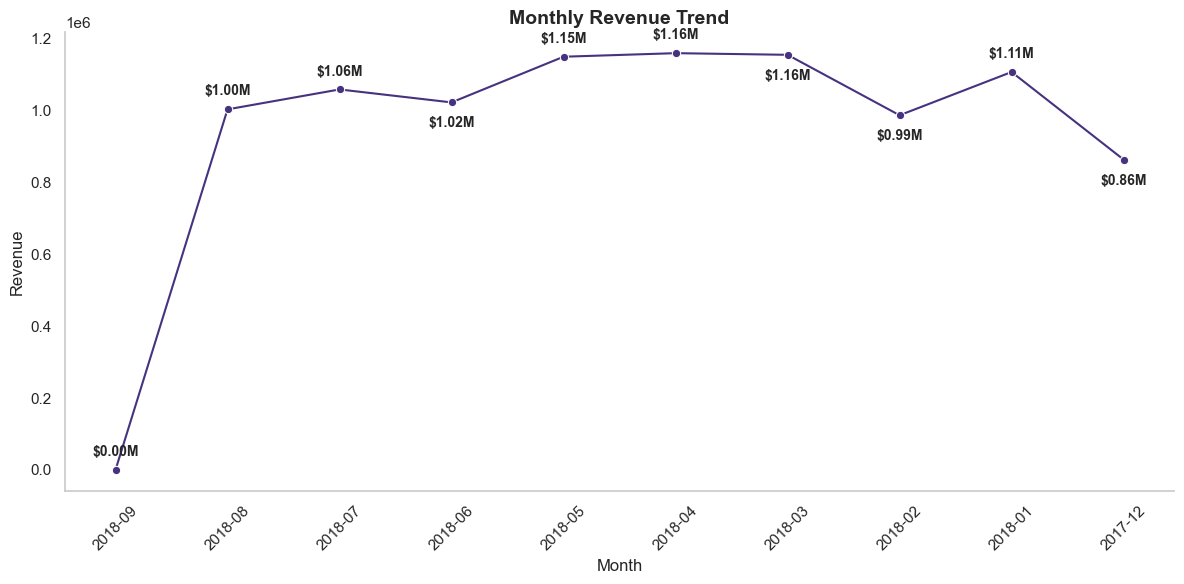

In [28]:
# Get monthly revenue data from the database
Monthly_revenue = run_query("""
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,  -- format date as YYYY-MM
        ROUND(SUM(oi.price + oi.freight_value), 2)    AS monthly_revenue  -- add price + shipping
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id  -- connect orders with their items
    GROUP BY order_month   -- one row per month
    ORDER BY order_month DESC  -- oldest month first
    LIMIT 10;
""")

# show the table so i can check the data looks right
display(Monthly_revenue)

# create a blank canvas for the chart, wide so months don't squish together
plt.figure(figsize=(12, 6))

# draw the line chart with dots at each month
ax = sns.lineplot(
    data=Monthly_revenue,
    x='order_month',
    y='monthly_revenue',
    marker='o'   # 'o' means circle dots on each point
)

# loop through every row to add a $ label near each dot
for i, row in Monthly_revenue.iterrows():
    x = row['order_month']     # the month (x position)
    y = row['monthly_revenue'] # the revenue (y position)

    # if revenue dropped compared to last month, put label below the dot
    # so it doesn't overlap with the line going down
    if i > 0 and y < Monthly_revenue.loc[i - 1, 'monthly_revenue']:
        vertical_offset = -18  # negative = move DOWN
    else:
        vertical_offset = 10   # positive = move UP

    # actually place the label near the dot
    plt.annotate(
        f'${y/1e6:.2f}M',        # format number like $1.18M
        (x, y),                   # start at the dot
        textcoords="offset points",  # then shift by pixels
        xytext=(0, vertical_offset), # 0 = don't move left/right
        ha='center',              # center the text horizontally
        fontsize=10,
        fontweight='bold'
    )

# chart title and axis labels
plt.title("Monthly Revenue Trend", fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')

# rotate month labels so they don't overlap each other
plt.xticks(rotation=45)

# remove the top and right borders (looks cleaner)
sns.despine()

# hide gridlines
ax.grid(False)

# auto-fix any layout issues before saving
plt.tight_layout()

# save as image file
plt.savefig('01_monthly_revenue.png', dpi=150)
plt.show()

## 📌 Insight: Revenue Trends & Seasonality
The monthly revenue analysis reveals a steady growth trajectory followed by a significant peak and a natural cooling period:

* **Growth Peak** : The business reached its highest performance between March and May 2018, consistently maintaining revenue above $1.15M

* **The Black Friday Effect** : A massive spike is visible in November 2017 the `$1.11M` peak , likely driven by Black Friday promotions, followed by a typical December dip to $0.86M

* **Operational Outlier**: The sharp drop in September 2018 suggests that the dataset ends early in that month, rather than a collapse in actual business performance

* **Strategic Value** : The stability in mid-2018 shows the platform successfully transitioned from seasonal holiday spikes to a higher, more consistent "baseline" of monthly revenue compared to 2017

## 🛒 Top Revenue-Generating Product Categories

This chart highlights the product categories contributing the highest overall revenue.

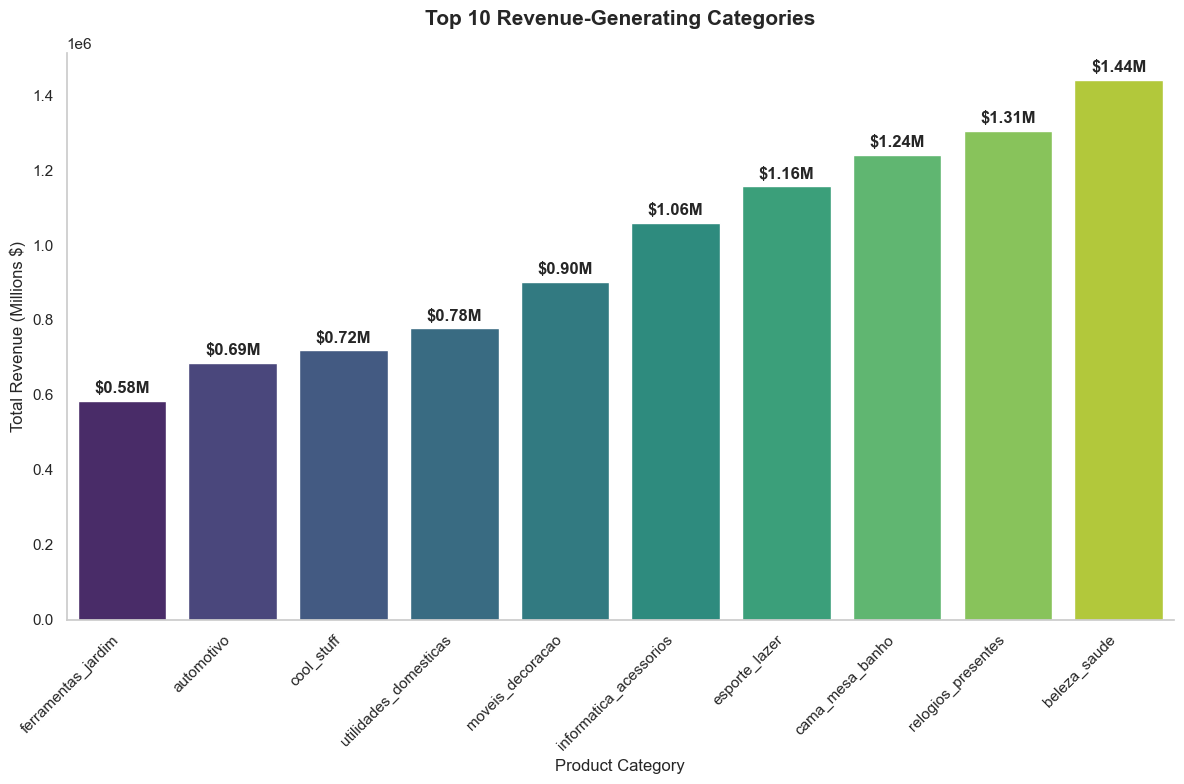

In [29]:
# Sort by revenue so it goes from smallest to largest
category_analysis = category_analysis.sort_values('total_revenue', ascending=True)

plt.figure(figsize=(12, 8))

# Plotting vertical (x = names, y = numbers)
ax = sns.barplot(
    data=category_analysis, 
    x='product_category', 
    y='total_revenue', 
    palette='viridis'
)
# Removing grid lines
ax.grid(False)
sns.despine()
# Add labels ABOVE the bars
for i, val in enumerate(category_analysis['total_revenue']):
    plt.text(
        i,              # X position 
        val + 20000,    # Y position
        f'${val/1e6:.2f}M', 
        ha='center',    # Center horizontally
        fontweight='bold'
    )
# Giving title, x and y labels
plt.title('Top 10 Revenue-Generating Categories', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total Revenue (Millions $)')
plt.xlabel('Product Category')

# Rotate the category names so they don't overlap
plt.xticks(rotation=45, ha='right')
# save as image file
plt.savefig('02_top_revenue_generating_categories.png', dpi=150)
plt.tight_layout()
plt.show()

## 📌 Insight: Category Revenue Performance
The bar chart reveals a clear hierarchy in product demand and spending power:

* **Revenue Leaders** : Health & Beauty (beleza_saude) and Watches & Gifts are the top drivers, both surpassing $1.3M. This confirms that high-ticket personal items are the platform's most valuable segments

* **Volume vs. Value** : While Bed/Bath/Table has a high order count, its revenue rank (3rd) suggests a lower average price point compared to the top two categories

* **Growth Opportunity** : The steady "staircase" decline toward Garden Tools ($0.58M) shows a healthy distribution of sales, but indicates that the bottom 5 categories have significant room for expansion through targeted promotions

## 🌍 Most Active Customer Cities

This chart displays the cities with the highest customer order activity across the platform

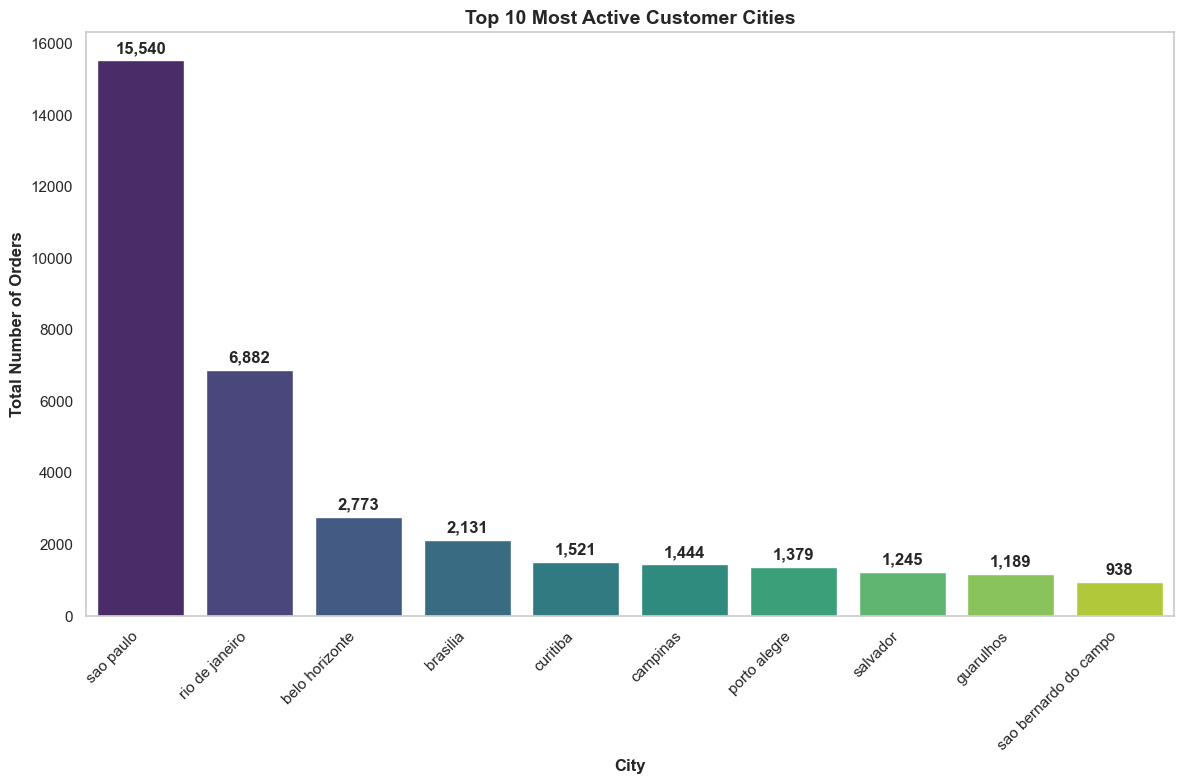

In [30]:
# create a blank canvas

plt.figure(figsize = (12,8))

# plotting vertical x and y

ax = sns.barplot(
    data=most_active_customer_cities,
    x='City',
    y='total_orders',
    palette='viridis'
)

# remove grid lines
ax.grid(False)

# add lables above the bars 

for i, val in enumerate(most_active_customer_cities['total_orders']):
    plt.text(
        i, # x position
        val+200, # y postion
        f'{val:,}', 
        ha='center',    # Center horizontally
        fontweight='bold'
        
    )

# prevent over lap
plt.xticks(rotation=45, ha='right')

# naming title, x and y
plt.title("Top 10 Most Active Customer Cities", fontsize = 14, fontweight = 'bold')
plt.xlabel("City", fontweight='bold')
plt.ylabel("Total Number of Orders", fontweight='bold')
# save as image file
plt.savefig('03_most_active_cities.png', dpi=150)
plt.tight_layout()
plt.show()


## 📌 Short Insight:

* **Market Concentration** : São Paulo is the absolute powerhouse, with nearly 16k orders, which is more than double the second-place city (Rio).

* **Regional Focus** : The top of the "staircase" is dominated by Southeast hubs, showing that the platform’s logistics and customer base are heavily centralized in Brazil's core economic zones.

## 💳 Payment Method Distribution

This chart visualizes the most commonly used payment methods across customer transactions.

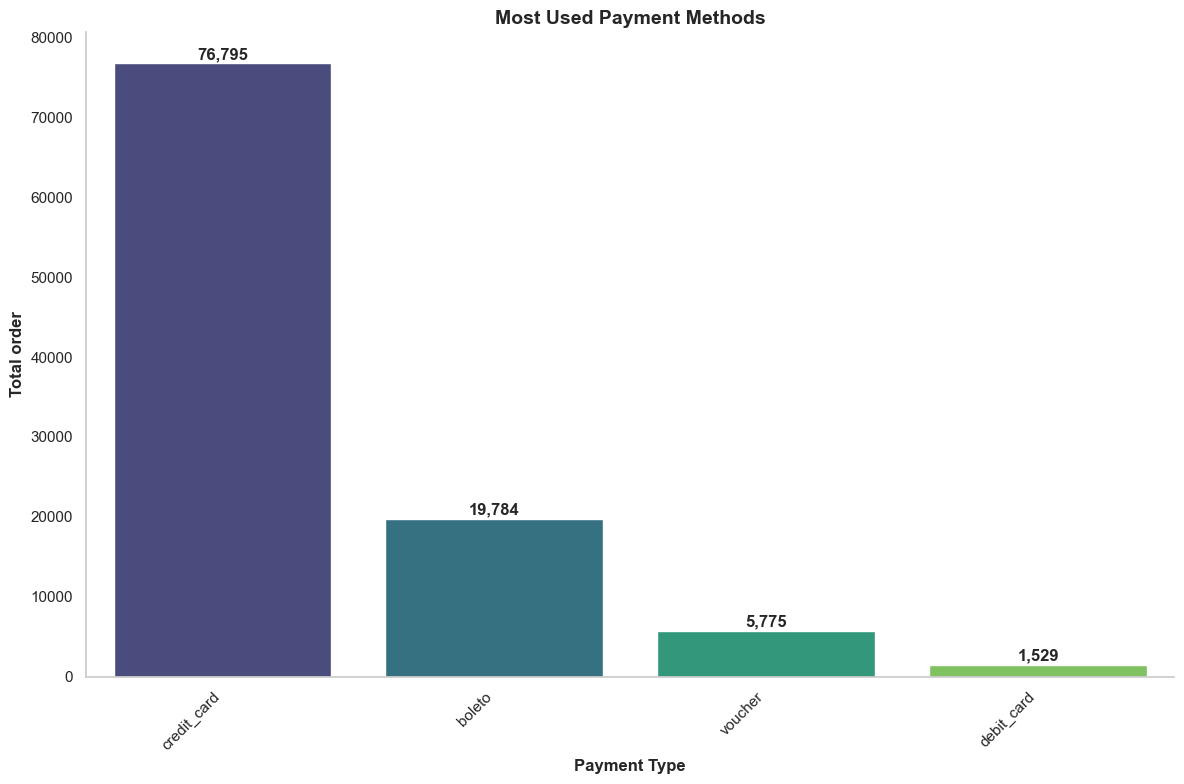

In [31]:
# create blank canvas for chart

plt.figure(figsize = (12,8))

# plotting x and y

ax = sns.barplot(
    data = Most_Used_Pay_method,
    x='payment_type',
    y='total_orders',
    palette = 'viridis'
)

#removing gridlines
ax.grid(False)
sns.despine()
# add data labels on top of bars
for i, val in enumerate(Most_Used_Pay_method['total_orders']):
    plt.text(
        i, # x position
        val+500, # y postion
        f'{val:,}',
        ha = 'center', # horizontally
        fontweight = 'bold'
        
    )

# prevent over lap

plt.xticks(rotation = 45, ha = 'right')

# naming title, x and y labels

plt.title("Most Used Payment Methods", fontsize = 14 , fontweight = 'bold')
plt.xlabel("Payment Type", fontweight='bold')
plt.ylabel("Total order", fontweight='bold')
# save as image file
plt.savefig('04_payment_method_distribution.png', dpi=150)
plt.tight_layout()
plt.show()

## 📌 Insight: Payment Method Dominance

* **Primary Driver** : Credit Card is the undisputed leader, accounting for approximately 74% of all transactions.

* **Secondary Hub** : Boleto remains the primary alternative (~19%), reflecting its importance in the Brazilian market.

* **Minor Method** : Vouchers and Debit Cards combined represent less than 7% of total volume, showing they are secondary to the core payment ecosystem.

* **Strategy** : The high reliance on credit cards likely fuels the platform's Average Order Value ($141) by allowing customers to use installments for higher-priced items.

## 🌎 Top Revenue-Generating States

This chart highlights the states contributing the highest overall revenue across the e-commerce platform.

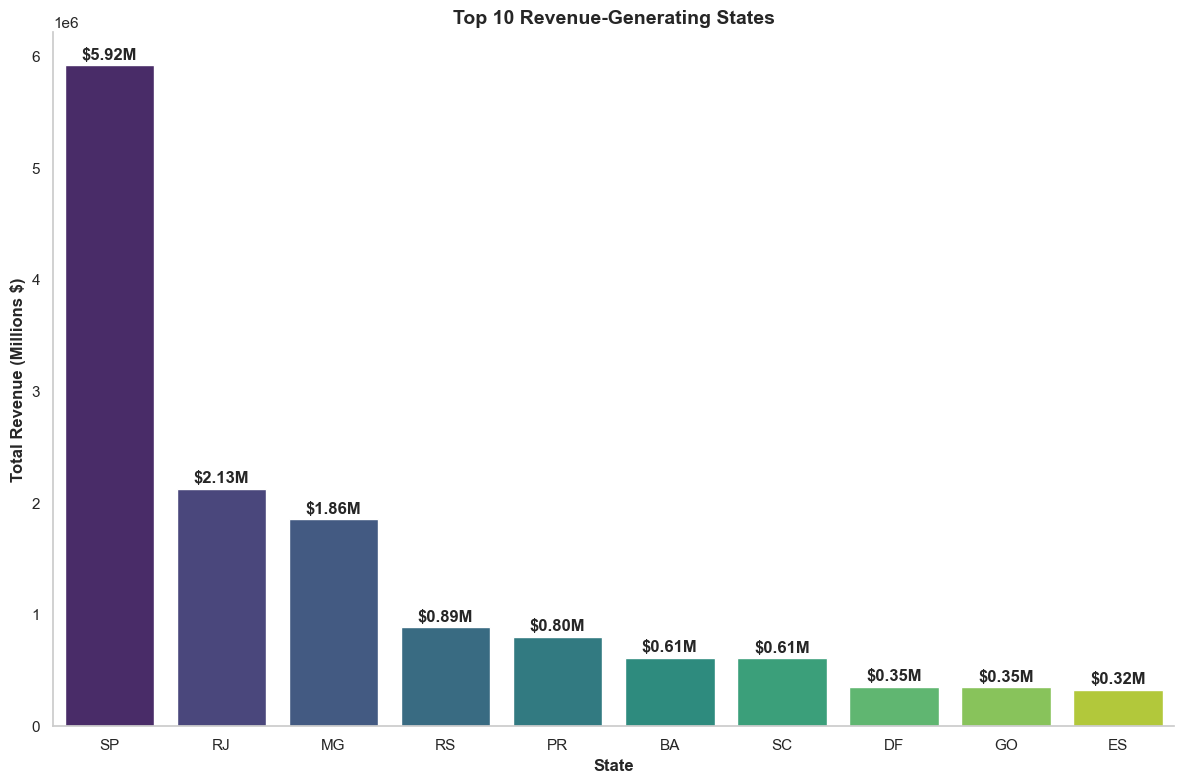

In [32]:
# create blank canvas for chart

plt.figure(figsize=(12,8))

# plotting x and y
ax = sns.barplot(
    data = state_revenue,
    x='customer_state',
    y='total_revenue',
    palette='viridis'
)

# add data labels on top of bars
for i, val in enumerate(state_revenue['total_revenue']):
    plt.text(
    i, # x position
    val + 50000, # y position
    f'${val/1e6:.2f}M', # format
    ha = 'center',
    fontweight='bold'

)

# removing grid
ax.grid(False)
sns.despine()
# naming titles and labels

plt.title("Top 10 Revenue-Generating States", fontsize=14, fontweight='bold')
plt.xlabel("State", fontweight = 'bold')
plt.ylabel("Total Revenue (Millions $)", fontweight='bold')
# save as image file
plt.savefig('05_Top_Revenue_Generating_states,png', dpi=150)
plt.tight_layout()

plt.show()


## 📌 Insight: Regional Revenue Dominance
The geographic distribution of sales reveals a highly centralized market concentrated in the Brazilian Southeast:

* **Market Epicenter** : São Paulo (SP) is the undisputed powerhouse, generating `$5.92M` This is nearly `3x` higher than the second-place state, confirming that the platform's core customer base and purchasing power reside in the industrial heart of Brazil.

* **The "Top 3" Concentration** : The trio of SP, RJ (Rio de Janeiro), and MG (Minas Gerais) accounts for a massive portion of total revenue `$9.9M+` Business performance is currently dependent on these three hubs.

* **Logistics & Expansion Gap** : Revenue drops significantly as we move toward states like BA (Bahia) and SC (Santa Catarina). This suggests that high freight costs or longer delivery times to these regions might be acting as a barrier to purchase.

* **Strategic Takeaway** : To grow beyond the Southeast, the platform should consider localized distribution centers in the South (PR/RS) or Northeast (BA) to reduce shipping friction and capture more market share.

## 🚚 Average Delivery Time Analysis

This visualization shows the average delivery duration across customer orders.

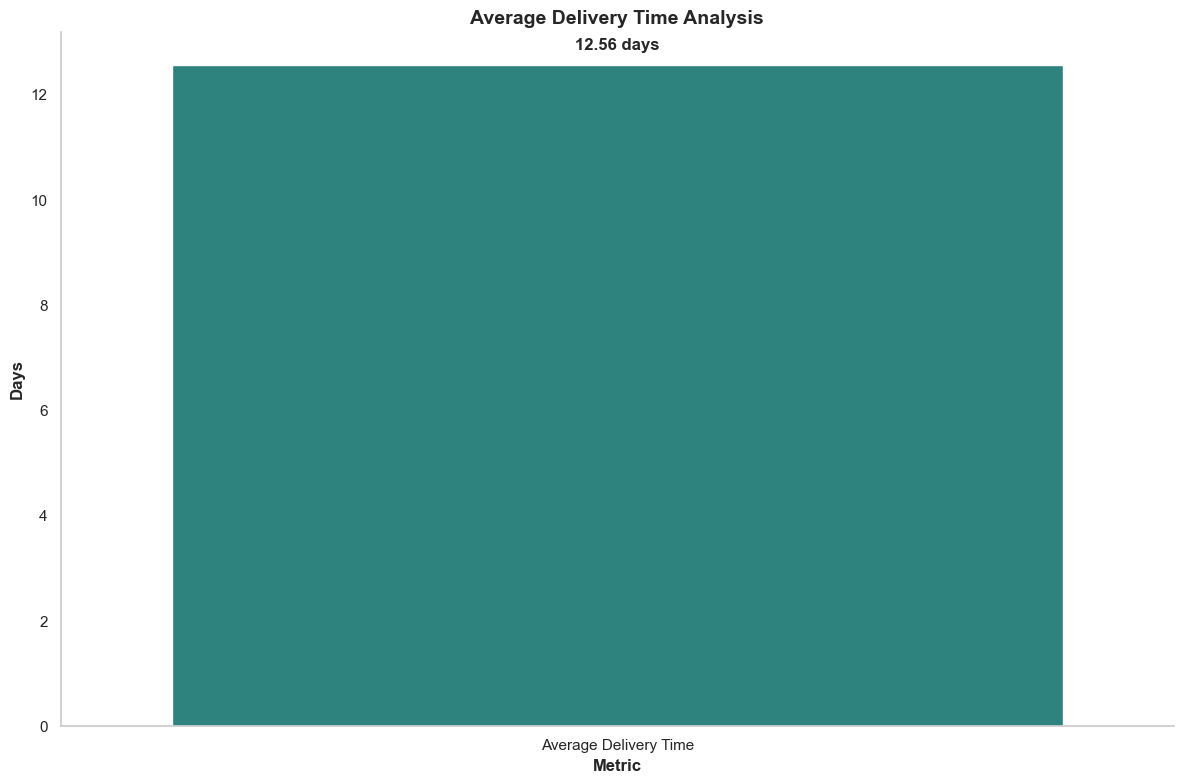

In [33]:
avg_days = Avg_del_time['avg_delivery_days'].values[0]

# create a blank canvas for the chart
plt.figure(figsize=(12, 8))

# plotting x and y
ax = sns.barplot(
    data=Avg_del_time,
    x=['Average Delivery Time'],  # label for the bar
    y='avg_delivery_days',
    palette='viridis'
)

# add data label on top of the bar
for i, val in enumerate(Avg_del_time['avg_delivery_days']):
    plt.text(
        i,              # x position 
        val + 0.3,      # y position 
        f'{val} days',  # format like "12.5 days"
        ha='center',
        fontweight='bold',
        fontsize=12
    )

# remove gridlines (looks cleaner)
ax.grid(False)
sns.despine() 

# naming titles and labels
plt.title("Average Delivery Time Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Metric", fontweight='bold')
plt.ylabel("Days", fontweight='bold')
# save as image

plt.savefig('06_average_delivery_time_analysis.png', dpi=150)

plt.tight_layout()  # auto-fix any layout issues
plt.show()

## 🚀 The "Win" Breakdown

* **The Baseline (12.56 Days)** : This is your current average. It’s your "Under-Promise" line.

* **The Trust Factor (89% Early)**: Almost 9 out of 10 customers get their package before the date you promised. This is why your reviews are likely high even if 12 days seems slow.

* **The Danger Zone (7.8% Delayed)** : These are your "Churn" customers. Even though the number is small, these 7,827 people are the ones most likely to never buy again.